# Detailed EDA on the Titanic Dataset - NumPy, Pandas, and Matplotlib

This notebook is a deep, hands-on dive into three core data-handling tools using a single real
dataset - the Titanic passenger list:

1. **NumPy** - working with the underlying numeric arrays directly (indexing, masking, vectorised
   statistics, handling missing values)
2. **Pandas** - loading, inspecting, cleaning and engineering features on the full dataset
3. **Exploratory Data Analysis (EDA)** with **Matplotlib** - univariate, bivariate and multivariate
   charts that uncover the patterns in who survived and who did not

The dataset is loaded directly from a public CSV, so this notebook needs no file upload and runs
top to bottom in Google Colab (`numpy`, `pandas` and `matplotlib` all ship with Colab by default,
and Colab has internet access to fetch the CSV).


## 0. Setup

We first import the libraries we need and set up a consistent, colorblind-aware color scheme and
chart style that we reuse for every chart in this notebook - this keeps every chart visually
consistent and makes categories (like `Sex`, `Pclass`, `Survived`) instantly recognisable by color
throughout.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# A small, fixed categorical palette (colorblind-aware, used in a fixed order throughout)
COLORS = {
    "blue": "#2a78d6",
    "orange": "#eb6834",
    "aqua": "#1baf7a",
    "yellow": "#eda100",
    "magenta": "#e87ba4",
    "green": "#008300",
    "violet": "#4a3aa7",
    "red": "#e34948",
}

# Fixed color assignments per category, used consistently in every chart below
SURVIVED_COLORS = {0: COLORS["blue"], 1: COLORS["orange"]}
SURVIVED_LABELS = {0: "Did not survive", 1: "Survived"}
SEX_COLORS = {"male": COLORS["blue"], "female": COLORS["orange"]}
PCLASS_COLORS = {1: COLORS["blue"], 2: COLORS["orange"], 3: COLORS["aqua"]}
EMBARKED_COLORS = {"S": COLORS["blue"], "C": COLORS["orange"], "Q": COLORS["aqua"]}

# Chart chrome: light neutral surface, muted gridlines/axes, dark ink text
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def style_ax(ax, grid_axis="y"):
    """Apply consistent, low-emphasis styling to a matplotlib Axes."""
    ax.grid(axis=grid_axis, alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
    ax.spines["bottom"].set_color("#c3c2b7")
    return ax


print("Setup complete.")


Setup complete.


## 1. Loading the Data

We load the classic Titanic passenger list directly from a public CSV. It has one row per
passenger, with their survival outcome, ticket class, name, demographics, family relationships,
fare paid, cabin, and port of embarkation.


In [2]:
TITANIC_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(TITANIC_URL)

print("shape:", df.shape)
df.head()


shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.columns.tolist()


['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

## Part 1 - NumPy

Pandas DataFrames are built on top of NumPy arrays. Before we work at the DataFrame level, it is
worth working directly with the underlying NumPy arrays for a few columns, since this is exactly
what happens "under the hood" of every Pandas operation.


In [4]:
# Pull a few columns out as plain NumPy arrays
age = df["Age"].to_numpy()
fare = df["Fare"].to_numpy()
pclass = df["Pclass"].to_numpy()
survived = df["Survived"].to_numpy()

print("type:", type(age))
print("age dtype/shape:", age.dtype, age.shape)
print("fare dtype/shape:", fare.dtype, fare.shape)
print("first 10 ages:", age[:10])


type: <class 'numpy.ndarray'>
age dtype/shape: float64 (891,)
fare dtype/shape: float64 (891,)
first 10 ages: [22. 38. 26. 35. 35. nan 54.  2. 27. 14.]


In [5]:
# Boolean masking: compare ages of survivors vs non-survivors directly on the arrays
survived_mask = survived == 1
died_mask = survived == 0

print("passengers who survived:", survived_mask.sum())
print("passengers who did not survive:", died_mask.sum())

# nan-safe statistics, since Age has missing values
print("\nmean age (survived):", np.nanmean(age[survived_mask]).round(2))
print("mean age (did not survive):", np.nanmean(age[died_mask]).round(2))


passengers who survived: 342
passengers who did not survive: 549

mean age (survived): 28.34
mean age (did not survive): 30.63


In [6]:
# Handling missing values at the NumPy level
missing_age_mask = np.isnan(age)
print("missing ages:", missing_age_mask.sum(), "out of", age.shape[0])

print("\nage statistics (ignoring missing values):")
print("  mean:  ", np.nanmean(age).round(2))
print("  median:", np.nanmedian(age).round(2))
print("  std:   ", np.nanstd(age).round(2))
print("  25th/50th/75th percentile:", np.nanpercentile(age, [25, 50, 75]).round(2))


missing ages: 177 out of 891

age statistics (ignoring missing values):
  mean:   29.7
  median: 28.0
  std:    14.52
  25th/50th/75th percentile: [20.12 28.   38.  ]


In [7]:
# Vectorised feature creation with np.where (no explicit Python loop needed)
is_child = np.where(age < 12, 1, 0)
print("number of children on board (age < 12):", is_child.sum())

# Vectorised fare-per-family-member style calculation using multiple arrays at once
family_size_np = df["SibSp"].to_numpy() + df["Parch"].to_numpy() + 1
fare_per_person = fare / family_size_np
print("average fare per person on the ticket:", np.nanmean(fare_per_person).round(2))


number of children on board (age < 12): 68
average fare per person on the ticket: 19.92


In [8]:
# Manually computing histogram bins with NumPy (this is exactly what plt.hist does internally)
valid_fare = fare[~np.isnan(fare)]
counts, bin_edges = np.histogram(valid_fare, bins=10)

for i in range(len(counts)):
    print(f"[{bin_edges[i]:7.2f}, {bin_edges[i+1]:7.2f}) -> {counts[i]:4d} passengers")


[   0.00,   51.23) ->  732 passengers
[  51.23,  102.47) ->  106 passengers
[ 102.47,  153.70) ->   31 passengers
[ 153.70,  204.93) ->    2 passengers
[ 204.93,  256.16) ->   11 passengers
[ 256.16,  307.40) ->    6 passengers
[ 307.40,  358.63) ->    0 passengers
[ 358.63,  409.86) ->    0 passengers
[ 409.86,  461.10) ->    0 passengers
[ 461.10,  512.33) ->    3 passengers


In [9]:
# Correlation matrix computed directly with NumPy
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
numeric_matrix = df[numeric_cols].dropna().to_numpy()

corr_matrix_np = np.corrcoef(numeric_matrix, rowvar=False)
corr_df = pd.DataFrame(corr_matrix_np, index=numeric_cols, columns=numeric_cols)
corr_df.round(2)


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.00,-0.36,-0.08,-0.02,0.09,0.27
Pclass,-0.36,1.00,-0.37,0.07,0.03,-0.55
Age,-0.08,-0.37,1.00,-0.31,-0.19,0.10
SibSp,-0.02,0.07,-0.31,1.00,0.38,0.14
Parch,0.09,0.03,-0.19,0.38,1.00,0.21
Fare,0.27,-0.55,0.10,0.14,0.21,1.00


## Part 2 - Pandas

Now we switch to working at the DataFrame level: inspecting the data, handling missing values,
filtering, and engineering new features that make the later charts much more informative.


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [12]:
# Missing values: count and percentage per column
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(1)

missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)


,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


In [13]:
# Selecting and filtering with loc / iloc and boolean conditions
print(df.iloc[0])              # first row, by position
print()
print(df.loc[0, ["Name", "Sex", "Age", "Survived"]])   # specific columns, by label


PassengerId                          1
Survived                             0
Pclass                               3
Name           Braund, Mr. Owen Harris
Sex                               male
Age                               22.0
SibSp                                1
Parch                                0
Ticket                       A/5 21171
Fare                              7.25
Cabin                              NaN
Embarked                             S
Name: 0, dtype: object

Name        Braund, Mr. Owen Harris
Sex                            male
Age                            22.0
Survived                          0
Name: 0, dtype: object


In [14]:
# Combined boolean filtering: first-class women who survived
first_class_women_survivors = df[
    (df["Pclass"] == 1) & (df["Sex"] == "female") & (df["Survived"] == 1)
]
print("count:", len(first_class_women_survivors))
first_class_women_survivors[["Name", "Age", "Fare"]].head()


count: 91


,Name,Age,Fare
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,71.2833
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,53.1000
11,"Bonnell, Miss. Elizabeth",58.0,26.5500
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",NaN,146.5208
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",49.0,76.7292


In [15]:
# Feature engineering: family size and travelling alone
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df[["Name", "SibSp", "Parch", "FamilySize", "IsAlone"]].head()


,Name,SibSp,Parch,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",1,0,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2,0
2,"Heikkinen, Miss. Laina",0,0,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2,0
4,"Allen, Mr. William Henry",0,0,1,1


In [16]:
# Feature engineering: extract a social title from the Name column
df["Title"] = df["Name"].str.extract(r",\s*([^.]+)\.")

# Normalise rare/alternate titles into a small, readable set
title_mapping = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Capt": "Rare", "Col": "Rare",
    "Don": "Rare", "Dr": "Rare", "Major": "Rare", "Rev": "Rare",
    "Sir": "Rare", "Jonkheer": "Rare", "Dona": "Rare",
}
df["Title"] = df["Title"].replace(title_mapping)
df["Title"] = df["Title"].where(df["Title"].isin(["Mr", "Mrs", "Miss", "Master", "Rare"]), "Rare")

df["Title"].value_counts()


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [17]:
# Feature engineering: age groups and fare bins
df["AgeGroup"] = pd.cut(
    df["Age"], bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
)

df["FareBin"] = pd.qcut(df["Fare"], q=4, labels=["Low", "Mid", "High", "Very High"], duplicates="drop")

df[["Age", "AgeGroup", "Fare", "FareBin"]].sample(5, random_state=42)


,Age,AgeGroup,Fare,FareBin
709,NaN,NaN,15.2458,High
439,31.0,Young Adult,10.5000,Mid
840,20.0,Young Adult,7.9250,Mid
720,6.0,Child,33.0000,Very High
39,14.0,Teen,11.2417,Mid


In [18]:
# Feature engineering: deck letter from the Cabin column
df["Deck"] = df["Cabin"].str[0]
df["Deck"] = df["Deck"].fillna("Unknown")

df["Deck"].value_counts()


Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [19]:
# Group-by aggregation: survival rate by sex, class and title
print("survival rate by Sex:")
print(df.groupby("Sex")["Survived"].mean().round(3))

print("\nsurvival rate by Pclass:")
print(df.groupby("Pclass")["Survived"].mean().round(3))

print("\nsurvival rate by Title:")
print(df.groupby("Title")["Survived"].mean().round(3).sort_values(ascending=False))


survival rate by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

survival rate by Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

survival rate by Title:
Title
Mrs       0.794
Miss      0.703
Master    0.575
Rare      0.348
Mr        0.157
Name: Survived, dtype: float64


In [20]:
# Pivot table: survival rate broken down by both class and sex at once
survival_pivot = pd.pivot_table(df, values="Survived", index="Pclass", columns="Sex", aggfunc="mean")
survival_pivot.round(3)


Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


In [21]:
# Crosstab: normalised counts of class vs survival outcome
pd.crosstab(df["Pclass"], df["Survived"], normalize="index").round(3)


Survived,0,1
Pclass,,
1,0.370,0.630
2,0.527,0.473
3,0.758,0.242


## Part 3 - Exploratory Data Analysis with Matplotlib

With the data cleaned and enriched, we now explore it visually. We move from **univariate** charts
(one variable at a time), to **bivariate** charts (a variable against survival), to **multivariate**
views that combine several variables at once.


### 3.1 Univariate: what does the passenger list look like on its own?

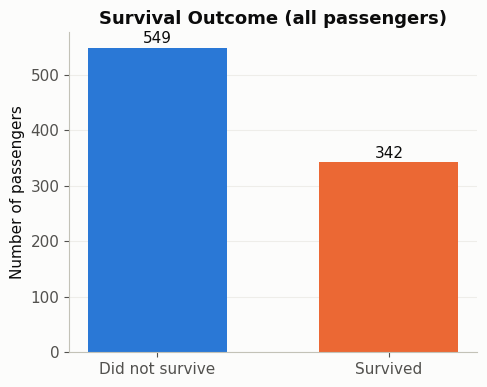

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df["Survived"].value_counts().sort_index()
bar_colors = [SURVIVED_COLORS[i] for i in counts.index]
bars = ax.bar([SURVIVED_LABELS[i] for i in counts.index], counts.values, color=bar_colors, width=0.6)

for rect, value in zip(bars, counts.values):
    ax.text(rect.get_x() + rect.get_width() / 2, value + 8, str(value), ha="center", color="#0b0b0b")

ax.set_ylabel("Number of passengers")
ax.set_title("Survival Outcome (all passengers)")
style_ax(ax)
plt.tight_layout()
plt.show()


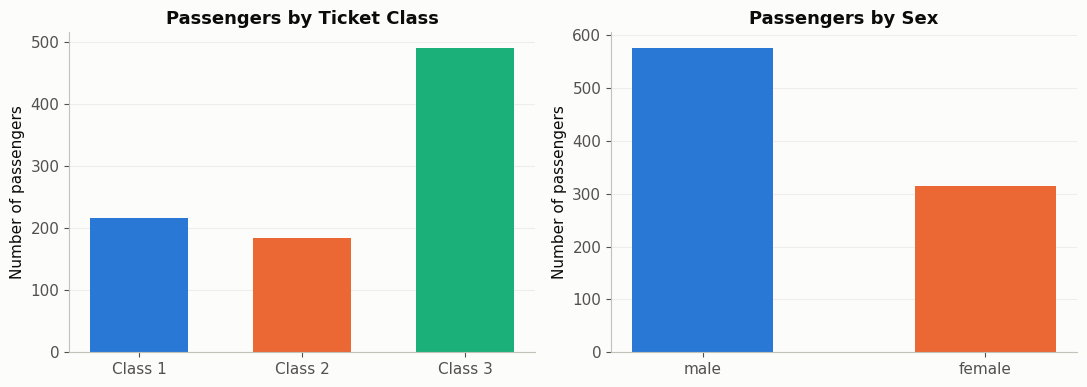

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pclass_counts = df["Pclass"].value_counts().sort_index()
axes[0].bar(
    [f"Class {c}" for c in pclass_counts.index], pclass_counts.values,
    color=[PCLASS_COLORS[c] for c in pclass_counts.index], width=0.6,
)
axes[0].set_ylabel("Number of passengers")
axes[0].set_title("Passengers by Ticket Class")
style_ax(axes[0])

sex_counts = df["Sex"].value_counts()
axes[1].bar(
    sex_counts.index, sex_counts.values,
    color=[SEX_COLORS[s] for s in sex_counts.index], width=0.5,
)
axes[1].set_ylabel("Number of passengers")
axes[1].set_title("Passengers by Sex")
style_ax(axes[1])

plt.tight_layout()
plt.show()


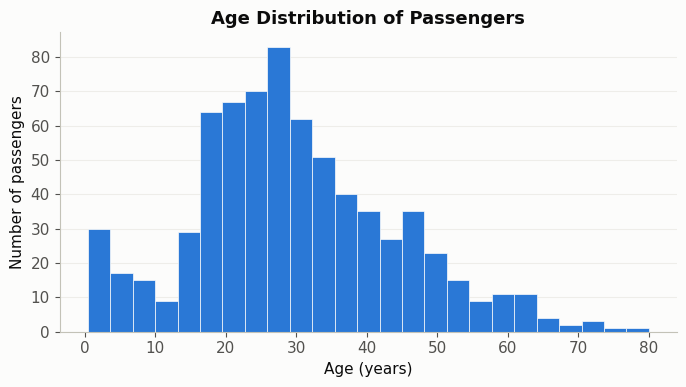

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["Age"].dropna(), bins=25, color=COLORS["blue"], edgecolor="#fcfcfb", linewidth=0.5)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of passengers")
ax.set_title("Age Distribution of Passengers")
style_ax(ax)
plt.tight_layout()
plt.show()


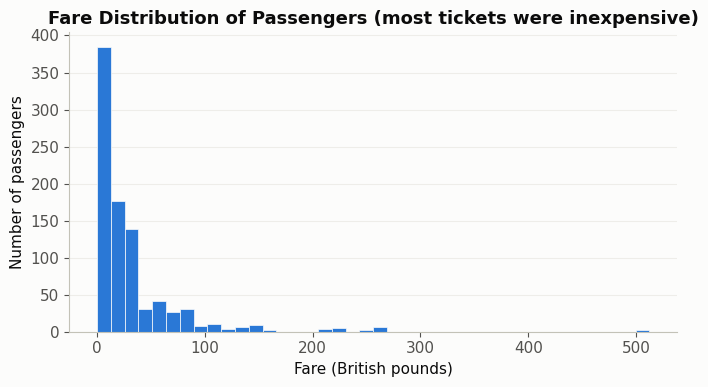

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["Fare"], bins=40, color=COLORS["blue"], edgecolor="#fcfcfb", linewidth=0.5)
ax.set_xlabel("Fare (British pounds)")
ax.set_ylabel("Number of passengers")
ax.set_title("Fare Distribution of Passengers (most tickets were inexpensive)")
style_ax(ax)
plt.tight_layout()
plt.show()


### 3.2 Bivariate: how does each variable relate to survival?

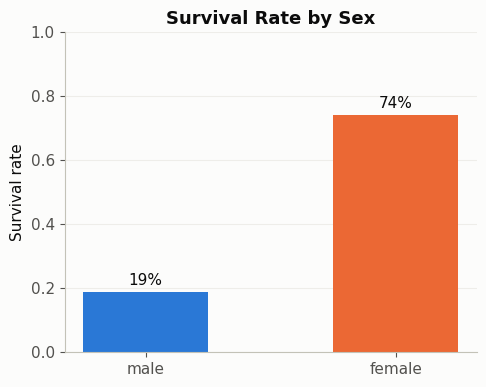

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))

rate_by_sex = df.groupby("Sex")["Survived"].mean().reindex(["male", "female"])
ax.bar(rate_by_sex.index, rate_by_sex.values, color=[SEX_COLORS[s] for s in rate_by_sex.index], width=0.5)

for i, value in enumerate(rate_by_sex.values):
    ax.text(i, value + 0.02, f"{value:.0%}", ha="center", color="#0b0b0b")

ax.set_ylim(0, 1)
ax.set_ylabel("Survival rate")
ax.set_title("Survival Rate by Sex")
style_ax(ax)
plt.tight_layout()
plt.show()


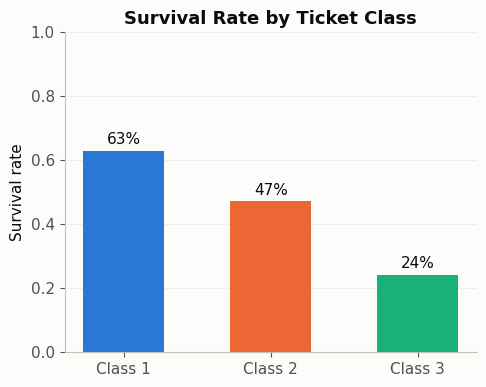

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))

rate_by_class = df.groupby("Pclass")["Survived"].mean()
labels = [f"Class {c}" for c in rate_by_class.index]
ax.bar(labels, rate_by_class.values, color=[PCLASS_COLORS[c] for c in rate_by_class.index], width=0.55)

for i, value in enumerate(rate_by_class.values):
    ax.text(i, value + 0.02, f"{value:.0%}", ha="center", color="#0b0b0b")

ax.set_ylim(0, 1)
ax.set_ylabel("Survival rate")
ax.set_title("Survival Rate by Ticket Class")
style_ax(ax)
plt.tight_layout()
plt.show()


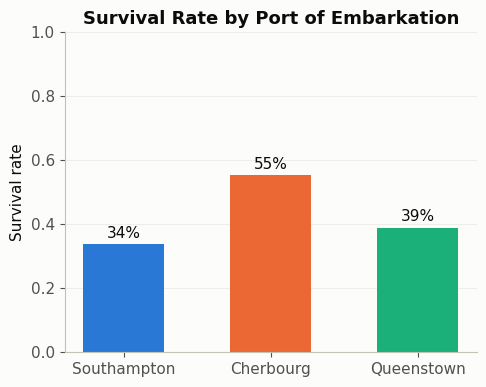

In [28]:
fig, ax = plt.subplots(figsize=(5, 4))

rate_by_embark = df.dropna(subset=["Embarked"]).groupby("Embarked")["Survived"].mean().reindex(["S", "C", "Q"])
port_names = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
ax.bar(
    [port_names[p] for p in rate_by_embark.index], rate_by_embark.values,
    color=[EMBARKED_COLORS[p] for p in rate_by_embark.index], width=0.55,
)

for i, value in enumerate(rate_by_embark.values):
    ax.text(i, value + 0.02, f"{value:.0%}", ha="center", color="#0b0b0b")

ax.set_ylim(0, 1)
ax.set_ylabel("Survival rate")
ax.set_title("Survival Rate by Port of Embarkation")
style_ax(ax)
plt.tight_layout()
plt.show()


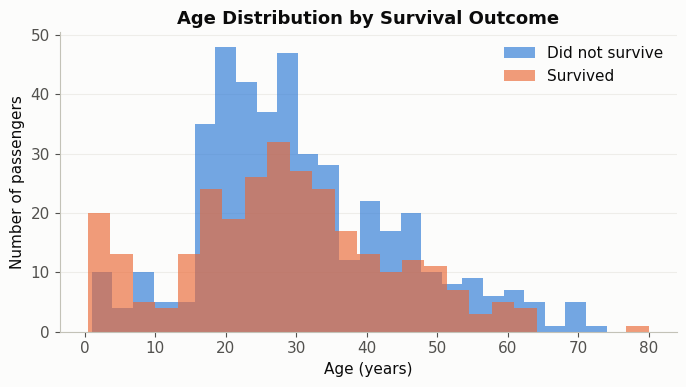

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    df.loc[df["Survived"] == 0, "Age"].dropna(), bins=25, alpha=0.65,
    label=SURVIVED_LABELS[0], color=SURVIVED_COLORS[0],
)
ax.hist(
    df.loc[df["Survived"] == 1, "Age"].dropna(), bins=25, alpha=0.65,
    label=SURVIVED_LABELS[1], color=SURVIVED_COLORS[1],
)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of passengers")
ax.set_title("Age Distribution by Survival Outcome")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()


/tmp/ipykernel_8777/1910599408.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


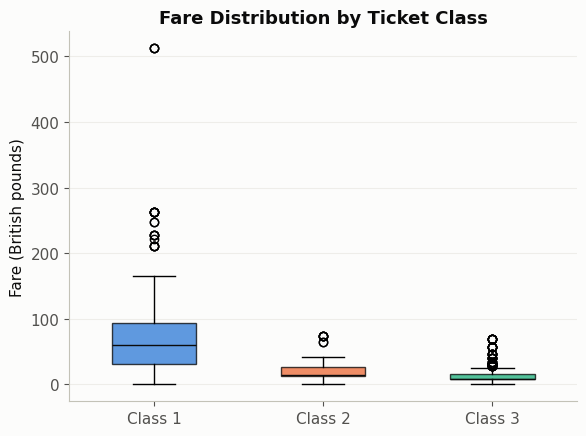

In [30]:
fig, ax = plt.subplots(figsize=(6, 4.5))

box_data = [df.loc[df["Pclass"] == c, "Fare"].dropna() for c in [1, 2, 3]]
bp = ax.boxplot(
    box_data, labels=["Class 1", "Class 2", "Class 3"], patch_artist=True,
    medianprops={"color": "#0b0b0b"}, widths=0.5,
)
for patch, c in zip(bp["boxes"], [1, 2, 3]):
    patch.set_facecolor(PCLASS_COLORS[c])
    patch.set_alpha(0.75)

ax.set_ylabel("Fare (British pounds)")
ax.set_title("Fare Distribution by Ticket Class")
style_ax(ax)
plt.tight_layout()
plt.show()


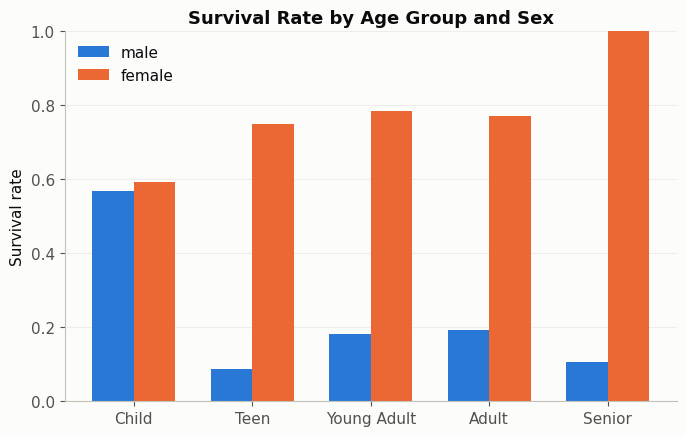

In [31]:
fig, ax = plt.subplots(figsize=(7, 4.5))

grouped = df.dropna(subset=["AgeGroup"]).groupby(["AgeGroup", "Sex"], observed=True)["Survived"].mean().unstack()
grouped = grouped.reindex(["Child", "Teen", "Young Adult", "Adult", "Senior"])

x = np.arange(len(grouped.index))
width = 0.35

ax.bar(x - width / 2, grouped["male"], width, label="male", color=SEX_COLORS["male"])
ax.bar(x + width / 2, grouped["female"], width, label="female", color=SEX_COLORS["female"])

ax.set_xticks(x)
ax.set_xticklabels(grouped.index)
ax.set_ylim(0, 1)
ax.set_ylabel("Survival rate")
ax.set_title("Survival Rate by Age Group and Sex")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()


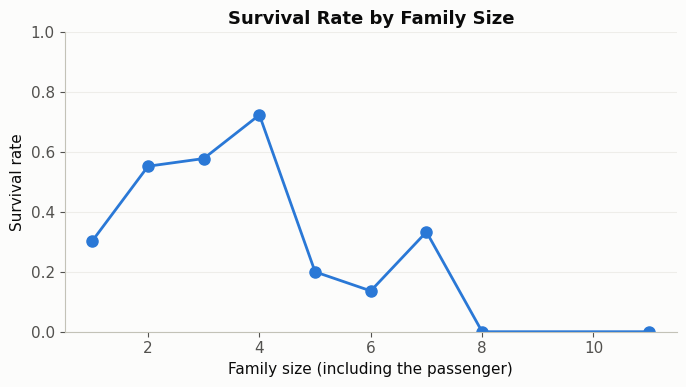

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))

rate_by_family = df.groupby("FamilySize")["Survived"].mean()
ax.plot(
    rate_by_family.index, rate_by_family.values,
    color=COLORS["blue"], linewidth=2, marker="o", markersize=8,
)

ax.set_xlabel("Family size (including the passenger)")
ax.set_ylabel("Survival rate")
ax.set_title("Survival Rate by Family Size")
ax.set_ylim(0, 1)
style_ax(ax)
plt.tight_layout()
plt.show()


### 3.3 Multivariate: combining several variables at once

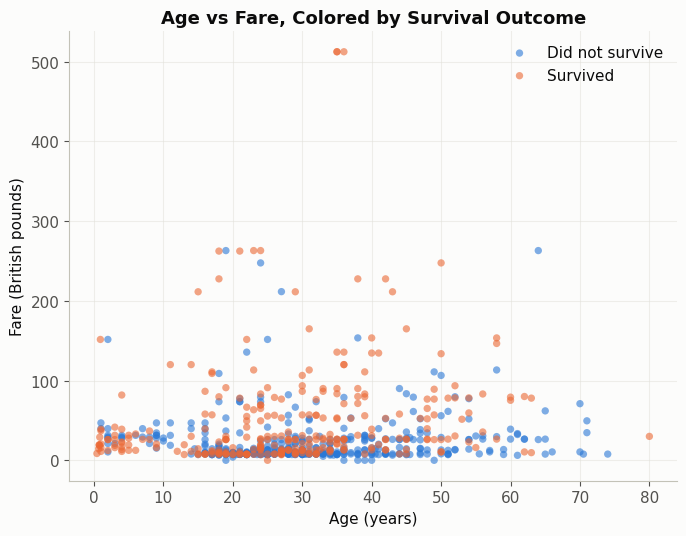

In [33]:
fig, ax = plt.subplots(figsize=(7, 5.5))

for outcome in [0, 1]:
    subset = df[df["Survived"] == outcome]
    ax.scatter(
        subset["Age"], subset["Fare"],
        color=SURVIVED_COLORS[outcome], label=SURVIVED_LABELS[outcome],
        alpha=0.6, s=28, edgecolor="none",
    )

ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare (British pounds)")
ax.set_title("Age vs Fare, Colored by Survival Outcome")
ax.legend(frameon=False)
style_ax(ax, grid_axis="both")
plt.tight_layout()
plt.show()


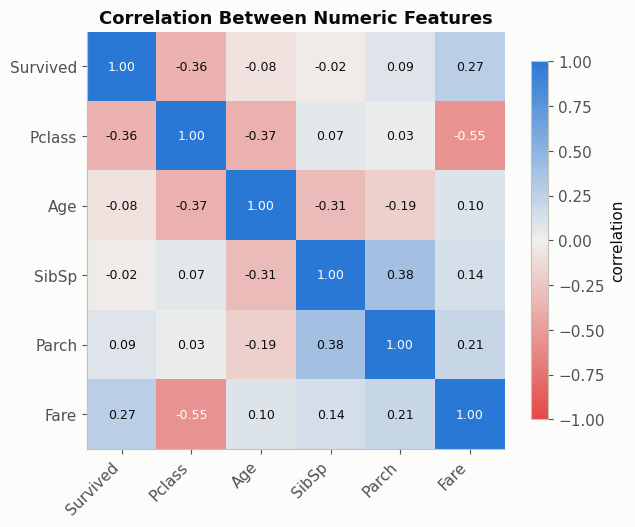

In [34]:
# A diverging blue <-> red colormap (blue = positive correlation, red = negative, gray = zero)
diverging_cmap = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#e34948", "#f0efec", "#2a78d6"]
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr_df.values, cmap=diverging_cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        value = corr_df.values[i, j]
        text_color = "#ffffff" if abs(value) > 0.55 else "#0b0b0b"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=9)

ax.set_title("Correlation Between Numeric Features")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
plt.tight_layout()
plt.show()


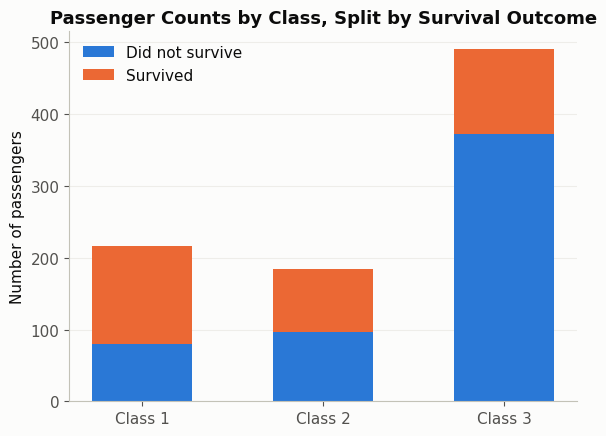

In [35]:
fig, ax = plt.subplots(figsize=(6, 4.5))

stacked = pd.crosstab(df["Pclass"], df["Survived"])
bottom = np.zeros(len(stacked))

for outcome in [0, 1]:
    values = stacked[outcome].values
    ax.bar(
        [f"Class {c}" for c in stacked.index], values, bottom=bottom,
        color=SURVIVED_COLORS[outcome], label=SURVIVED_LABELS[outcome], width=0.55,
    )
    bottom += values

ax.set_ylabel("Number of passengers")
ax.set_title("Passenger Counts by Class, Split by Survival Outcome")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()


## Summary of Insights

A few patterns come through clearly from the charts above:

Survival was strongly related to sex: women survived at a much higher rate than men, consistent
with a "women and children first" evacuation pattern. Ticket class mattered a great deal too - first
class passengers survived at a noticeably higher rate than third class passengers, which lines up
with the fare and deck differences between classes. Children had a meaningfully better survival rate
than adults, and passengers travelling with a small family (roughly 2 to 4 people including
themselves) tended to survive more often than those travelling completely alone or in very large
family groups. Fare and ticket class are, unsurprisingly, strongly correlated with each other, and
both show a visible (if moderate) relationship with survival, which the correlation heatmap makes
easy to compare all at once alongside age and family size.

This notebook combined NumPy for low-level array operations and vectorised statistics, Pandas for
data inspection, cleaning and feature engineering, and Matplotlib for building every chart from
univariate distributions up to multivariate comparisons, all on a single real dataset.
